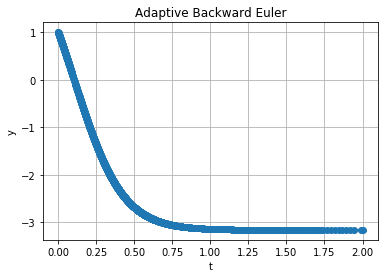

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return y**2 - 10

def fprime(y):
    return 2*y

def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y  # initial guess

    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)

        if abs(g_prime_val) < tol:
            break

        y_new = y_next - g_val / g_prime_val

        if abs(y_new - y_next) < tol:
            return y_new

        y_next = y_new

    return y_next


def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]

    h = h_init
    t = t0
    y = y0

    while t < tf:
        if t + h > tf:
            h = tf - t

        y_full = backward_euler_step(f, y, t, h, tol, max_iter)

        h_half = h / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)

        error = abs(y_full - y_half_2)

        if error > tol:
            h /= 2
            continue

        t += h
        y = y_half_2
        t_values.append(t)
        y_values.append(y)

        if error < tol / 2:
            h *= 2

    return np.array(t_values), np.array(y_values)


# Example run
t_values, y_values = backward_euler_adaptive(
    f=f,
    y0=1,
    t0=0,
    tf=2,
    h_init=0.1,
    tol=1e-6
)

plt.plot(t_values, y_values, marker="o")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Adaptive Backward Euler")
plt.grid(True)
plt.show()